In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# all_data.zip 압축 해제

import os
import zipfile

# 경로 설정
zip_path = "/content/drive/MyDrive/Colab Notebooks/스프린트/codeit_1팀/med data/all_data.zip"
extract_path = "/content/all_data"

# 압축 해제
if os.path.exists(zip_path):
    print(f"해제 시작: {zip_path}")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"해제 완료: {extract_path}")
else:
    print(f"파일을 찾을 수 없습니다.: {zip_path}")

# 해제된 폴더 구조 확인
!ls -R /content/all_data | head -n 20

파일을 찾을 수 없습니다.: /content/drive/MyDrive/Colab Notebooks/스프린트/codeit_1팀/med data/all_data.zip


'ls'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [7]:
# 첫번째 파일의 어노테이션과 이미지 출력
import os
import json
from PIL import Image
import matplotlib.pyplot as plt

print("--- annotation 파일 목록 (상위 5개) ---")
!ls /content/all_data/all_data/train_annotations | head -n 5

print("\n--- 첫 번째 annotation 파일 내용 ---")
ann_dir = "/content/all_data/all_data/train_annotations"
first_file = os.listdir(ann_dir)[0]
!cat {os.path.join(ann_dir, first_file)}

ann_path = os.path.join(ann_dir, first_file)

# JSON 읽기
with open(ann_path, 'r') as f:
    data = json.load(f)

# file_name 추출
file_name = data["images"][0]["file_name"]

img_dir = "/content/all_data/all_data/train_images"
img_path = os.path.join(img_dir, file_name)

print("\n\n이미지:", file_name)

img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()

--- annotation 파일 목록 (상위 5개) ---

--- 첫 번째 annotation 파일 내용 ---


'ls'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


FileNotFoundError: [WinError 3] 지정된 경로를 찾을 수 없습니다: '/content/all_data/all_data/train_annotations'

In [ ]:
import os
import json
from tqdm import tqdm

check_json_dir = "/content/all_data/all_data/train_annotations"

bad_files = []

print("BBox 개수 유효성 검사 시작...")
json_files = [f for f in os.listdir(check_json_dir) if f.endswith('.json')]

for j_file in json_files:
    file_path = os.path.join(check_json_dir, j_file)
    with open(file_path, 'r', encoding='utf-8') as f:
        try:
            data = json.load(f)
            for ann in data.get('annotations', []):
                bbox = ann.get('bbox', [])
                # bbox가 리스트가 아니거나 길이가 4가 아닌 경우 적발
                if not isinstance(bbox, list) or len(bbox) != 4:
                    bad_files.append({
                        "file_name": j_file,
                        "wrong_bbox": bbox,
                        "length": len(bbox) if isinstance(bbox, list) else "Not a list"
                    })
        except Exception as e:
            print(f"파일 읽기 오류 ({j_file}): {e}")

# 결과 출력
print(f"총 {len(bad_files)}개의 불량 객체")
print("-" * 50)

if bad_files:
    for i, item in enumerate(bad_files[:10]):
        print(f"[{i+1}] 파일명: {item['file_name']}")
        print(f"    ㄴ 실제 bbox 값: {item['wrong_bbox']} (길이: {item['length']})")

    if len(bad_files) > 10:
        print(f"... 외 {len(bad_files) - 10}개의 오류가 더 있습니다.")
else:
    print("모든 파일의 BBox가 유효함")

BBox 개수 유효성 검사 시작...
총 19개의 불량 객체
--------------------------------------------------
[1] 파일명: K-003614-016232-025469-030308_0_2_0_2_75_000_200.json
    ㄴ 실제 bbox 값: [46.805, 368, 248] (길이: 3)
[2] 파일명: K-016235-016262-027733-034597_0_2_0_2_70_000_200.json
    ㄴ 실제 bbox 값: [61214, 121, 849, 254, 241] (길이: 5)
[3] 파일명: K-000250-005002-012081-023223_0_2_0_2_75_000_200.json
    ㄴ 실제 bbox 값: [652, 705239, 472] (길이: 3)
[4] 파일명: K-015710-019861-020238-034597_0_2_0_2_90_000_200.json
    ㄴ 실제 bbox 값: [12, 132, 463, 463, 408] (길이: 5)
[5] 파일명: K-011220-020238-027653-030308_0_2_0_2_90_000_200.json
    ㄴ 실제 bbox 값: [59, 112402, 405] (길이: 3)
[6] 파일명: K-003544-016551-029451-033878_0_2_0_2_90_000_200.json
    ㄴ 실제 bbox 값: [146, 259, 211.202] (길이: 3)
[7] 파일명: K-016232-016235-019861-030308_0_2_0_2_75_000_200.json
    ㄴ 실제 bbox 값: [87, 829, 176] (길이: 3)
[8] 파일명: K-003832-016232-033026_0_2_0_2_70_000_200.json
    ㄴ 실제 bbox 값: [632, 193, 190] (길이: 3)
[9] 파일명: K-005094-005886-019552-044834_0_2_0_2_70_000_200.

# YOLO

In [4]:
!pip install -U ultralytics

from ultralytics import YOLO

   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 55.1 MB/s  0:00:00
   ---------------------------------------- 0.0/824.0 kB ? eta -:--:--
   ---------------------------------------- 824.0/824.0 kB 48.3 MB/s  0:00:00
   ---------------------------------------- 0.0/47.0 MB ? eta -:--:--
   --- ------------------------------------ 4.2/47.0 MB 20.4 MB/s eta 0:00:03
   ------------------ --------------------- 22.3/47.0 MB 53.7 MB/s eta 0:00:01
   ---------------------------------- ----- 40.1/47.0 MB 63.9 MB/s eta 0:00:01
   ---------------------------------------- 47.0/47.0 MB 62.9 MB/s  0:00:00

   ---------------------------------------- 0/4 [polars-runtime-32]
   ---------------------------------------- 0/4 [polars-runtime-32]
   ---------------------------------------- 0/4 [polars-runtime-32]
   ---------- ----------------------------- 1/4 [polars]
   ---------- ----------------------------- 1/4 [polars]
   ----

In [3]:
import os
import json
import random
import yaml
import shutil
from glob import glob
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict
from sklearn.model_selection import train_test_split
import cv2
import numpy as np

# 경로 설정
PILL_DATASET_ROOT = "/content/all_data/all_data"
SRC_IMG_DIR = os.path.join(PILL_DATASET_ROOT, "train_images")
SRC_JSON_DIR = os.path.join(PILL_DATASET_ROOT, "train_annotations")

YOLO_ROOT = "/content/pill_yolo"

PILL_NAMES = [
    "보령부스파정 5mg", "뮤테란캡슐 100mg", "일양하이트린정 2mg", "기넥신에프정(은행엽엑스)(수출용)",
    "무코스타정(레바미피드)(비매품)", "알드린정", "뉴로메드정(옥시라세탐)", "에어탈정(아세클로페낙)",
    "리렉스펜정 300mg/PTP", "아빌리파이정 10mg", "다보타민큐정 10mg/병", "써스펜8시간이알서방정 650mg",
    "에빅사정(메만틴염산염)(비매품)", "리피토정 20mg", "크레스토정 20mg", "가바토파정 100mg",
    "동아가바펜틴정 800mg", "오마코연질캡슐(오메가-3-산에틸에스테르90)", "리리카캡슐 150mg", "종근당글리아티린연질캡슐(콜린알포세레이트)",
    "콜리네이트연질캡슐 400mg", "트루비타정 60mg/병", "스토가정 10mg", "노바스크정 5mg",
    "마도파정", "플라빅스정 75mg", "엑스포지정 5/160mg", "아토르바정 10mg",
    "라비에트정 20mg", "리피로우정 20mg", "자누비아정 50mg", "맥시부펜이알정 300mg",
    "놀텍정 10mg", "자누메트정 50/850mg", "큐시드정 31.5mg/PTP", "아모잘탄정 5/100mg",
    "트윈스타정 40/5mg", "카나브정 60mg", "울트라셋이알서방정", "졸로푸트정 100mg",
    "트라젠타정(리나글립틴)", "비모보정 500/20mg", "레일라정", "리바로정 4mg",
    "트라젠타듀오정 2.5/850mg", "아질렉트정(라사길린메실산염)", "자누메트엑스알서방정 100/1000mg", "글리아타민연질캡슐",
    "신바로정", "에스원엠프정 20mg", "글리틴정(콜린알포세레이트)", "제미메트서방정 50/1000mg",
    "아토젯정 10/40mg", "로수젯정10/5밀리그램", "로수바미브정 10/20mg", "카발린캡슐 25mg"
]

In [ ]:
def apply_clahe(img_path):         # 이미지를 읽고 CLAHE 적용 후 반환
    img = cv2.imread(img_path)
    if img is None: return None
    
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    # CLAHE 적용 (대비 강화)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    
    # 다시 BGR로 복원
    lab = cv2.merge((l, a, b))
    result = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    return result

In [8]:
# YOLO 학습용 데이터셋 빌드(JSON → TXT 변환)
# 1. bbox 유효성 검사에서 발견된 불량 bbox(길이가 4가 아닌 경우)를 자동 필터링
# 2. 이미지 내에 정상 객체가 하나라도 있으면 저장하고, 불량 객체만 제외
# 3. 모든 객체가 불량인 이미지(현재 약 4장)는 학습셋에서 완전히 격리


def extract_combo_key(stem):
    # 파일명에서 알약코드 조합만 추출하여 동일 객체의 중복 학습을 방지
    # 동일한 알약 조합을 70/75/90 같은 촬영 조건만 바꾼 유사 이미지가 있기 때문에 split 시 이미지 단위가 아니라 조합 그룹 단위로 처리하여 하나의 그룹으로 묶음
    # 예: K-001-002_0_2_70_000 → K-001-002 (조합 ID만 반환)
    return stem.split("_")[0]

def process_items(items, split, clahe_p=0.5):
    # 불량 bbox를 가진 객체나 이미지를 자동으로 제외하며 변환
    dst_img_dir = os.path.join(YOLO_ROOT, 'images', split)
    dst_lbl_dir = os.path.join(YOLO_ROOT, 'labels', split)

    saved_count = 0
    skipped_count = 0
    clahe_applied_count = 0 # 얼마나 적용됐는지 확인용

    for item in tqdm(items, desc=f"Processing {split}"):
        try:
            with open(item['json'], 'r', encoding='utf-8') as f:
                data = json.load(f)

            img_info = data['images'][0]
            width, height = img_info['width'], img_info['height']

            lines = []
            for ann in data.get('annotations', []):
                bbox = ann.get('bbox', [])

                # bbox 유효성 검사 (4개가 아니면 무시)
                if not isinstance(bbox, list) or len(bbox) != 4:
                    continue

                cls_id = ann['category_id']
                x, y, w, h = bbox

                # YOLO 정규화 좌표 계산
                # bbox: [x, y, w, h] → YOLO: [x_center, y_center, w, h]
                xc = (x + w / 2.0) / width
                yc = (y + h / 2.0) / height
                wn = w / width
                hn = h / height

                # 계산된 좌표가 유효한지도 확인 (0 ~1 사이)
                if not all(0 <= val <= 1 for val in [xc, yc, wn, hn]): continue
                lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")

            if lines:
                dst_img_path = os.path.join(dst_img_dir, os.path.basename(item['img']))
                
                # --- CLAHE 적용 로직 시작 ---
                # 설정한 확률(clahe_p)에 따라 CLAHE 적용 결정
                if np.random.random() < clahe_p:
                    processed_img = apply_clahe(item['img'])
                    if processed_img is not None:
                        cv2.imwrite(dst_img_path, processed_img) # 처리된 이미지 저장
                        clahe_applied_count += 1
                    else:
                        shutil.copy2(item['img'], dst_img_path) # 실패 시 원본 복사
                else:
                    shutil.copy2(item['img'], dst_img_path) # 원본 복사
                # --- CLAHE 적용 로직 끝 ---

                label_path = os.path.join(dst_lbl_dir, f"{item['stem']}.txt")
                with open(label_path, 'w', encoding='utf-8') as f:
                    f.write("\n".join(lines))
                saved_count += 1
            else:
                skipped_count += 1

        except Exception as e:
            print(f"Error processing {item['stem']}: {e}")
            skipped_count += 1

    print(f"\n{split} 완료: 저장 {saved_count}개 (CLAHE 적용: {clahe_applied_count}개), 제외 {skipped_count}개")
def build_yolo_dataset():
    # 데이터셋 빌드 메인 함수
    # 초기화 및 폴더 생성
    if os.path.exists(YOLO_ROOT): shutil.rmtree(YOLO_ROOT)
    for split in ['train', 'val']:
        os.makedirs(os.path.join(YOLO_ROOT, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(YOLO_ROOT, 'labels', split), exist_ok=True)

    # 이미지/JSON 매칭 및 그룹화
    img_paths = sorted(glob(os.path.join(SRC_IMG_DIR, "*.png")))
    combo_groups = defaultdict(list)

    for ip in img_paths:
        stem = Path(ip).stem
        json_path = os.path.join(SRC_JSON_DIR, stem + ".json")
        if os.path.exists(json_path):
            combo_key = extract_combo_key(stem)
            combo_groups[combo_key].append({'img': ip, 'json': json_path, 'stem': stem})

    # 그룹 단위 분할 (shuffle 대신 Group Split 적용)
    combo_keys = sorted(list(combo_groups.keys()))
    train_keys, val_keys = train_test_split(combo_keys, test_size=0.2, random_state=42)

    # 아이템 리스트 생성 및 처리
    train_items = [item for k in train_keys for item in combo_groups[k]]
    val_items = [item for k in val_keys for item in combo_groups[k]]

    process_items(train_items, 'train')
    process_items(val_items, 'val')

    # data.yaml 생성
    yaml_content = {
        'path': YOLO_ROOT,
        'train': 'images/train',
        'val': 'images/val',
        'nc': len(PILL_NAMES),
        'names': PILL_NAMES
    }
    with open(os.path.join(YOLO_ROOT, 'data.yaml'), 'w', encoding='utf-8') as f:
        yaml.dump(yaml_content, f, allow_unicode=True, sort_keys=False)

    print(f"\nYOLO 데이터셋 빌드 완료: {YOLO_ROOT}")
    print(f"Train 이미지: {len(train_items)} | Val 이미지: {len(val_items)}")

In [13]:
build_yolo_dataset()

Processing train: 100%|██████████| 6436/6436 [02:15<00:00, 47.65it/s]



train 완료: 저장됨 6432개, 제외됨 4개


Processing val: 100%|██████████| 1603/1603 [00:35<00:00, 44.91it/s]


val 완료: 저장됨 1603개, 제외됨 0개

YOLO 데이터셋 빌드 완료: /content/pill_yolo
Train 이미지: 6436 | Val 이미지: 1603


In [15]:
# 학습
model = YOLO("yolo26m.pt")

model.train(
    data=os.path.join(YOLO_ROOT, 'data.yaml'),
    epochs=20,
    imgsz=768,
    batch=16,
    device=0,
    project='Pill_Project',
    name='yolo26m_train',
    exist_ok=True,
    pretrained=True,
    workers=4,
    seed=42,
    deterministic=True,
    patience=20,
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pill_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26m_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspecti

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d08b412c320>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.03

# 추론 시각화


In [ ]:
if not os.path.exists("NanumGothic.ttf"):
    os.system("wget -q https://hangeul.pstatic.net/hangeul_static/webfont/NanumGothic/NanumGothic.ttf")
    print("폰트 다운로드 완료!")

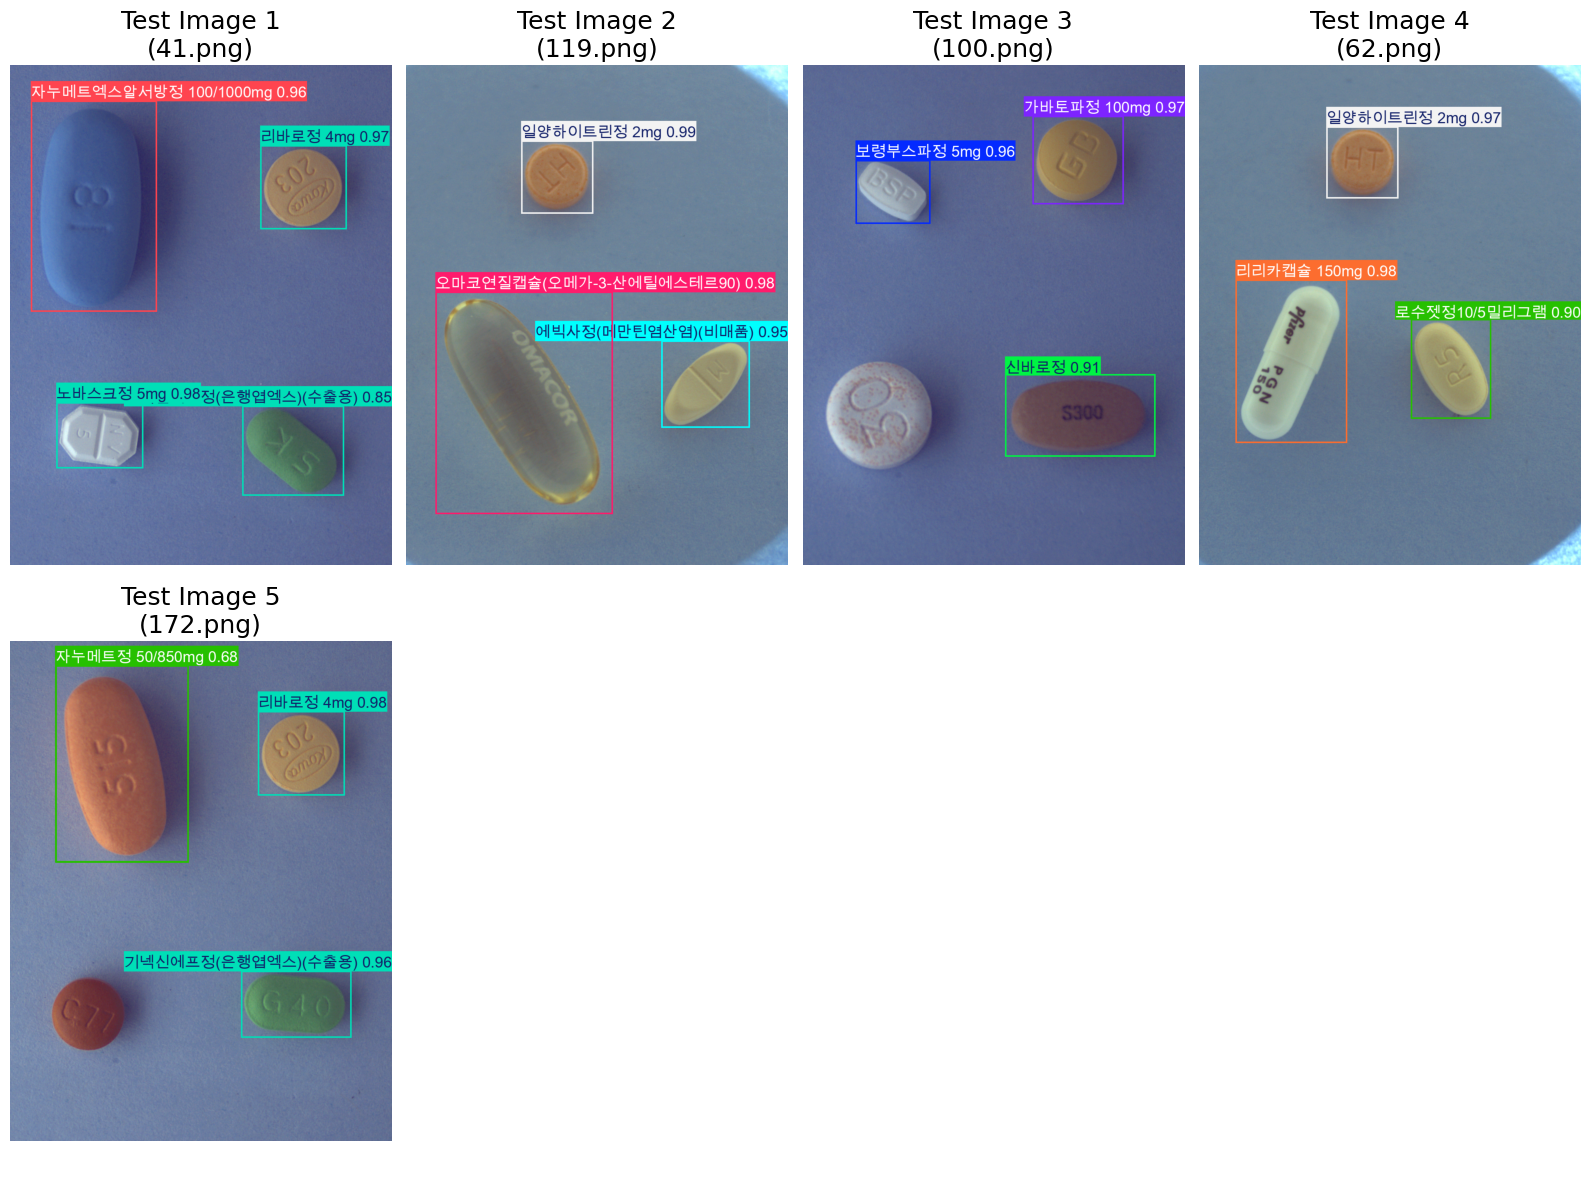

In [ ]:
# 열 4로 고정하여 출력

import cv2
import math
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

MODEL_PATH = "/content/runs/detect/Pill_Project/yolo26m_train/weights/best.pt"
model = YOLO(MODEL_PATH)

TEST_IMG_DIR = "/content/drive/MyDrive/Colab Notebooks/스프린트/new_merged_annonation/test_images_116"



### 전체 이미지 중 5장 랜덤으로 출력할 때 ###
NUM_SAMPLES = 5
all_test_imgs = glob(os.path.join(TEST_IMG_DIR, "*.png"))

random.seed(42)
sample_img_paths = random.sample(all_test_imgs, min(len(all_test_imgs), NUM_SAMPLES))
# =========================================================
### 특정 파일 지정 출력할 때 ###
# target_files = ['198.png', '189.png', '100.png']
# sample_img_paths = [os.path.join(TEST_IMG_DIR, f) for f in target_files]
# =========================================================


COLS = 4
rows = math.ceil(len(sample_img_paths) / COLS)

plt.figure(figsize=(16, 6 * rows))

for i, img_path in enumerate(sample_img_paths):
    # 모델 추론
    results = model.predict(source=img_path, conf=0.25, imgsz=768, verbose=False)

    res_plotted = results[0].plot(
            font="NanumGothic.ttf",
            labels=True,
            conf=True,
            line_width=4,
            font_size=None
    )

    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, COLS, i + 1)
    plt.imshow(res_rgb)

    img_name = Path(img_path).name
    plt.title(f"Test Image {i+1}\n({img_name})", fontsize=18)
    plt.axis('off')

for j in range(len(sample_img_paths), rows * COLS):
    plt.subplot(rows, COLS, j + 1)
    plt.axis('off')

plt.tight_layout()
plt.show()